In [19]:
# ==============================================================================
# 1. IMPORTS & CONFIGURATION
# ==============================================================================
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
from sklearn.metrics import f1_score
from scipy.stats import entropy
import os
import time

# Configuration pour CPU (i7)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Force l'utilisation du CPU si un GPU traîne
tf.config.set_visible_devices([], 'GPU')

print(f"TensorFlow Version: {tf.__version__}")
print("Mode: CPU Optimized")

# Hyperparamètres
MAX_LEN = 150       # Longueur max séquence
D_MODEL = 32        # Petit pour rapidité CPU
N_REC = 1           # Récurrence interne
N_SUP = 3           # Deep Supervision steps
BATCH_SIZE = 64
EPOCHS = 250

TensorFlow Version: 2.20.0
Mode: CPU Optimized


In [20]:
# ==============================================================================
# 2. CHARGEMENT & PRÉPARATION DES DONNÉES
# ==============================================================================
print("\n📥 Chargement des données bpRNA...")

# Mappages
# 0 est réservé au PADDING (masqué)
SEQ_MAP = {'A': 1, 'C': 2, 'G': 3, 'U': 4, 'T': 4, 'N': 0} 
STRUCT_MAP = {'.': 1, '(': 2, ')': 3, '[': 1, ']': 1, '{': 1, '}': 1, '>': 1, '<': 1}

def load_and_process_data(max_len=150, max_samples=3000):
    # Streaming pour éviter de saturer la RAM
    dataset = load_dataset("multimolecule/bprna", split="train", streaming=True)
    
    X_list, Y_list = [], []
    count = 0
    
    for row in dataset:
        seq, struct = row['sequence'], row['secondary_structure']
        if len(seq) <= max_len:
            # Tokenisation Sequence
            x_seq = [SEQ_MAP.get(c.upper(), 0) for c in seq]
            # Tokenisation Structure
            y_seq = [STRUCT_MAP.get(c, 1) for c in struct] # Default to '.' (1) if unknown
            
            # Padding
            x_pad = x_seq + [0] * (max_len - len(x_seq))
            y_pad = y_seq + [0] * (max_len - len(y_seq))
            
            X_list.append(x_pad)
            Y_list.append(y_pad)
            count += 1
            
        if count >= max_samples:
            break
            
    return np.array(X_list), np.array(Y_list)

# Exécution du chargement
try:
    X, Y = load_and_process_data(MAX_LEN)
    print(f"✅ Données chargées. X shape: {X.shape}, Y shape: {Y.shape}")
except Exception as e:
    print(f"⚠️ Erreur chargement (connexion internet ?): {e}")
    print("⚠️ Utilisation de données synthétiques pour test...")
    X = np.random.randint(1, 5, (100, MAX_LEN))
    Y = np.random.randint(1, 4, (100, MAX_LEN))

# Split Train/Val (90% Train, 10% Val pour calculer les métriques proprement)
split_idx = int(0.9 * len(X))
X_train, Y_train = X[:split_idx], Y[:split_idx]
X_val, Y_val = X[split_idx:], Y[split_idx:]

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).shuffle(1024).batch(BATCH_SIZE)
# Pas de shuffle/batch pour la validation manuelle, on le fera en une passe


📥 Chargement des données bpRNA...
✅ Données chargées. X shape: (3000, 150), Y shape: (3000, 150)


In [21]:
# ==============================================================================
# 3. ARCHITECTURE DU MODÈLE (TRM)
# ==============================================================================

class TinyBlock(layers.Layer):
    def __init__(self, d):
        super().__init__()
        self.ln = layers.LayerNormalization()
        self.fc1 = layers.Dense(4 * d, activation="gelu")
        self.fc2 = layers.Dense(d)

    def call(self, u):
        h = self.ln(u)
        h = self.fc1(h)
        h = self.fc2(h)
        return u + h

class RNATRM(keras.Model):
    def __init__(self, input_vocab=5, output_vocab=4, d=64, max_len=150, n_rec=2, T=3, Nsup=4):
        super().__init__()
        self.d = d
        self.n_rec = n_rec
        self.T = T
        self.Nsup = Nsup

        # Embeddings
        self.emb = layers.Embedding(input_vocab, d)
        self.pos = self.add_weight(shape=(1, max_len, d), initializer="random_normal", trainable=True)

        # États Latents
        self.y0 = self.add_weight(shape=(1, max_len, d), initializer="zeros", trainable=True)
        self.z0 = self.add_weight(shape=(1, max_len, d), initializer="zeros", trainable=True)

        # Cerveau Récursif
        self.block1 = TinyBlock(d)
        self.block2 = TinyBlock(d)

        # Têtes de sortie
        # Output vocab size = 4 (0=Pad, 1=., 2=(, 3=))
        self.to_structure = layers.Dense(output_vocab) 
        self.halt_head = layers.Dense(1)

    def tiny_net(self, u):
        u = self.block1(u)
        u = self.block2(u)
        return u

    def update_z(self, x, y, z): return self.tiny_net(x + y + z)
    def update_y(self, y, z): return self.tiny_net(y + z)

    def call(self, x_tokens, y_true=None, training=False):
        B = tf.shape(x_tokens)[0]
        L = tf.shape(x_tokens)[1]

        x = self.emb(x_tokens) + self.pos[:, :L, :]
        y = tf.tile(self.y0[:, :L, :], [B, 1, 1])
        z = tf.tile(self.z0[:, :L, :], [B, 1, 1])

        losses = []

        for step in range(self.Nsup):
            # Boucle Temporelle
            for t in range(self.T):
                if t < self.T - 1:
                    # Thinking (No Gradient)
                    for _ in range(self.n_rec):
                        z = tf.stop_gradient(self.update_z(x, y, z))
                    y = tf.stop_gradient(self.update_y(y, z))
                else:
                    # Learning (Gradient)
                    for _ in range(self.n_rec):
                        z = self.update_z(x, y, z)
                    y = self.update_y(y, z)

            logits = self.to_structure(y)
            halt_p = tf.sigmoid(tf.reduce_mean(self.halt_head(y), axis=1))

            if y_true is not None:
                # 1. Cross Entropy Maskée (Vital pour la Perplexity)
                ce_raw = tf.keras.losses.sparse_categorical_crossentropy(y_true, logits, from_logits=True)
                mask = tf.cast(tf.not_equal(y_true, 0), dtype=ce_raw.dtype)
                ce = tf.reduce_sum(ce_raw * mask) / (tf.reduce_sum(mask) + 1e-6)
                losses.append(ce)

            # Detach
            y = tf.stop_gradient(y)
            z = tf.stop_gradient(z)

        if y_true is None:
            return logits, halt_p

        return tf.add_n(losses) / len(losses)

In [22]:
# ==============================================================================
# 4. INITIALISATION
# ==============================================================================
print("\n🏗️ Construction du modèle...")
tf.keras.backend.clear_session()

# On utilise output_vocab=4 (Pad, ., (, ))
model = RNATRM(input_vocab=5, output_vocab=4, d=D_MODEL, max_len=MAX_LEN, n_rec=N_REC, Nsup=N_SUP)

# Init Dummy pour construire les poids
dummy_x = tf.zeros((1, MAX_LEN))
model(dummy_x)
print(f"✅ Modèle construit (Params: ~{model.count_params()})")

optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)


🏗️ Construction du modèle...
✅ Modèle construit (Params: ~31557)


In [23]:
# ==============================================================================
# 5. FONCTIONS MÉTRIQUES (F1, Entropy, Perplexity)
# ==============================================================================

def calculate_metrics(model, x_val, y_val):
    """Calcule F1, Entropie et Perplexité sur le set de validation."""
    
    # 1. Prédiction (Batch par batch pour éviter OOM)
    logits_list = []
    # On fait des mini-batchs de 32 pour la validation
    dataset_val = tf.data.Dataset.from_tensor_slices(x_val).batch(32)
    
    for batch_x in dataset_val:
        logits, _ = model(batch_x, training=False)
        logits_list.append(logits)
    
    logits = tf.concat(logits_list, axis=0) # [N, L, 4]
    probs = tf.nn.softmax(logits).numpy()   # [N, L, 4]
    preds = np.argmax(probs, axis=-1)       # [N, L]
    
    # 2. Masquage (On ignore le padding 0)
    mask = (y_val != 0)
    y_true_flat = y_val[mask]
    y_pred_flat = preds[mask]
    probs_flat = probs[mask]
    
    # --- METRIQUE 1 : F1-SCORE ---
    # Labels: 1=., 2=(, 3=)
    f1 = f1_score(y_true_flat, y_pred_flat, average='weighted', labels=[1, 2, 3], zero_division=0)
    
    # --- METRIQUE 2 : ENTROPIE (Incertitude) ---
    # entropy() de scipy calcule -sum(p*log(p))
    ent_vals = entropy(probs_flat, axis=-1)
    avg_ent = np.mean(ent_vals)
    
    # --- METRIQUE 3 : PERPLEXITY ---
    # Perplexity = exp(CrossEntropy)
    # On recalcule la CE proprement
    ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_val, logits, from_logits=True)
    # Appliquer masque TensorFlow
    mask_tf = tf.cast(tf.not_equal(y_val, 0), dtype=ce_loss.dtype)
    mean_ce = tf.reduce_sum(ce_loss * mask_tf) / (tf.reduce_sum(mask_tf) + 1e-6)
    perplexity = tf.exp(mean_ce).numpy()
    
    return f1, avg_ent, perplexity

In [24]:
# ==============================================================================
# 6. BOUCLE D'ENTRAÎNEMENT OPTIMISÉE (XLA + Validation espacée)
# ==============================================================================

# 1. Compilation XLA (Turbo)
@tf.function(jit_compile=True)
def train_step(x, y):
    with tf.GradientTape() as tape:
        loss = model(x, y_true=y, training=True)
    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    return loss

print(f"\n🚀 Démarrage entraînement (Mode Turbo XLA)...")

history = {'loss': [], 'f1': [], 'perplexity': [], 'entropy': []}

# Validation frequency (toutes les 5 époques pour gagner du temps)
VAL_FREQ = 5 

for epoch in range(EPOCHS):
    start_time = time.time()
    total_loss = 0.0
    steps = 0
    
    # --- TRAINING ---
    for x_batch, y_batch in train_ds:
        loss = train_step(x_batch, y_batch)
        total_loss += loss
        steps += 1
    
    avg_loss = total_loss / steps
    history['loss'].append(avg_loss)
    
    # --- VALIDATION (Seulement si nécessaire) ---
    epoch_time = time.time() - start_time
    
    # On valide à la première, la dernière, et tous les VAL_FREQ
    if (epoch + 1) % VAL_FREQ == 0 or epoch == 0 or epoch == EPOCHS - 1:
        val_f1, val_ent, val_ppl = calculate_metrics(model, X_val, Y_val)
        
        # On remplit les trous dans l'historique pour garder les graphiques cohérents
        # (Ou on ajoute simplement les nouvelles valeurs)
        history['f1'].append(val_f1)
        history['entropy'].append(val_ent)
        history['perplexity'].append(val_ppl)
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | "
              f"PPL: {val_ppl:.2f} | F1: {val_f1:.4f} | Ent: {val_ent:.4f} | "
              f"Time: {epoch_time:.1f}s")
    else:
        # On répète la dernière valeur connue pour le graphique ou on met NaN
        last_f1 = history['f1'][-1] if history['f1'] else 0
        history['f1'].append(last_f1)
        history['entropy'].append(history['entropy'][-1] if history['entropy'] else 0)
        history['perplexity'].append(history['perplexity'][-1] if history['perplexity'] else 0)
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")


🚀 Démarrage entraînement (Mode Turbo XLA)...


c:\Users\anase\Documents\Master_II\Deep Learning avance\.venv\Lib\site-packages\keras\src\optimizers\base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['rnatrm/variable_1', 'rnatrm/variable_2', 'rnatrm/dense_5/kernel', 'rnatrm/dense_5/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 01 | Loss: 341.1519 | PPL: inf | F1: 0.5136 | Ent: 0.0040 | Time: 28.7s
Epoch 02 | Loss: 36.9012 | Time: 16.0s
Epoch 03 | Loss: 24.2276 | Time: 12.9s
Epoch 04 | Loss: 21.7787 | Time: 13.7s
Epoch 05 | Loss: 20.8452 | PPL: inf | F1: 0.5441 | Ent: 0.0076 | Time: 13.6s
Epoch 06 | Loss: 19.3128 | Time: 11.0s
Epoch 07 | Loss: 17.9204 | Time: 14.0s
Epoch 08 | Loss: 15.9555 | Time: 12.3s
Epoch 09 | Loss: 15.9068 | Time: 12.5s
Epoch 10 | Loss: 16.6149 | PPL: inf | F1: 0.5418 | Ent: 0.0002 | Time: 10.6s
Epoch 11 | Loss: 18.3128 | Time: 10.3s
Epoch 12 | Loss: 15.0207 | Time: 10.3s
Epoch 13 | Loss: 15.8825 | Time: 12.0s
Epoch 14 | Loss: 13.9727 | Time: 15.1s
Epoch 15 | Loss: 14.1896 | PPL: inf | F1: 0.5692 | Ent: 0.0059 | Time: 14.1s
Epoch 16 | Loss: 13.3340 | Time: 13.9s
Epoch 17 | Loss: 14.8362 | Time: 10.6s
Epoch 18 | Loss: 14.0284 | Time: 10.5s
Epoch 19 | Loss: 13.5538 | Time: 10.6s
Epoch 20 | Loss: 12.9267 | PPL: inf | F1: 0.5676 | Ent: 0.0046 | Time: 9.9s
Epoch 21 | Loss: 14.9685 | Tim

In [25]:
# ==============================================================================
# 7. SAUVEGARDE & TEST FINAL
# ==============================================================================
model.save_weights("rnatrm_final_metrics.weights.h5")
print("\n✅ Entraînement terminé et modèle sauvegardé.")

# Petit test visuel final sur un exemple de validation
print("\n--- Exemple de Prédiction (Validation) ---")
idx = 0
x_sample = X_val[idx:idx+1]
y_true_sample = Y_val[idx]

logits, _ = model(x_sample, training=False)
pred = np.argmax(logits, axis=-1)[0]

# Décodage
REV_STRUCT = {v: k for k, v in STRUCT_MAP.items()}
truth_str = "".join([REV_STRUCT.get(t, '') for t in y_true_sample if t!=0])
pred_str = "".join([REV_STRUCT.get(t, '') for t in pred if t!=0])[:len(truth_str)]

print(f"VRAI   : {truth_str}")
print(f"PRÉDIT : {pred_str}")


✅ Entraînement terminé et modèle sauvegardé.

--- Exemple de Prédiction (Validation) ---
VRAI   : (((((((((<<<<((((((((<<<<(((((((<<<<<<<<<<<<))))<<)))<<<))))))<))<(((((<<<<<<(((((<(((<<<<))))))))<<<<<)))))<)))))))))
PRÉDIT : (<((<(((<<<<<((((((<(<(<<(((((()(<<<<<<<<<<<)<<)<<)))<<<(<))<)<))<(((((<<<<<<<<((((((()<<<)))<)))))<<)))))))<)))))))<)


📊 Affichage des courbes d'apprentissage...


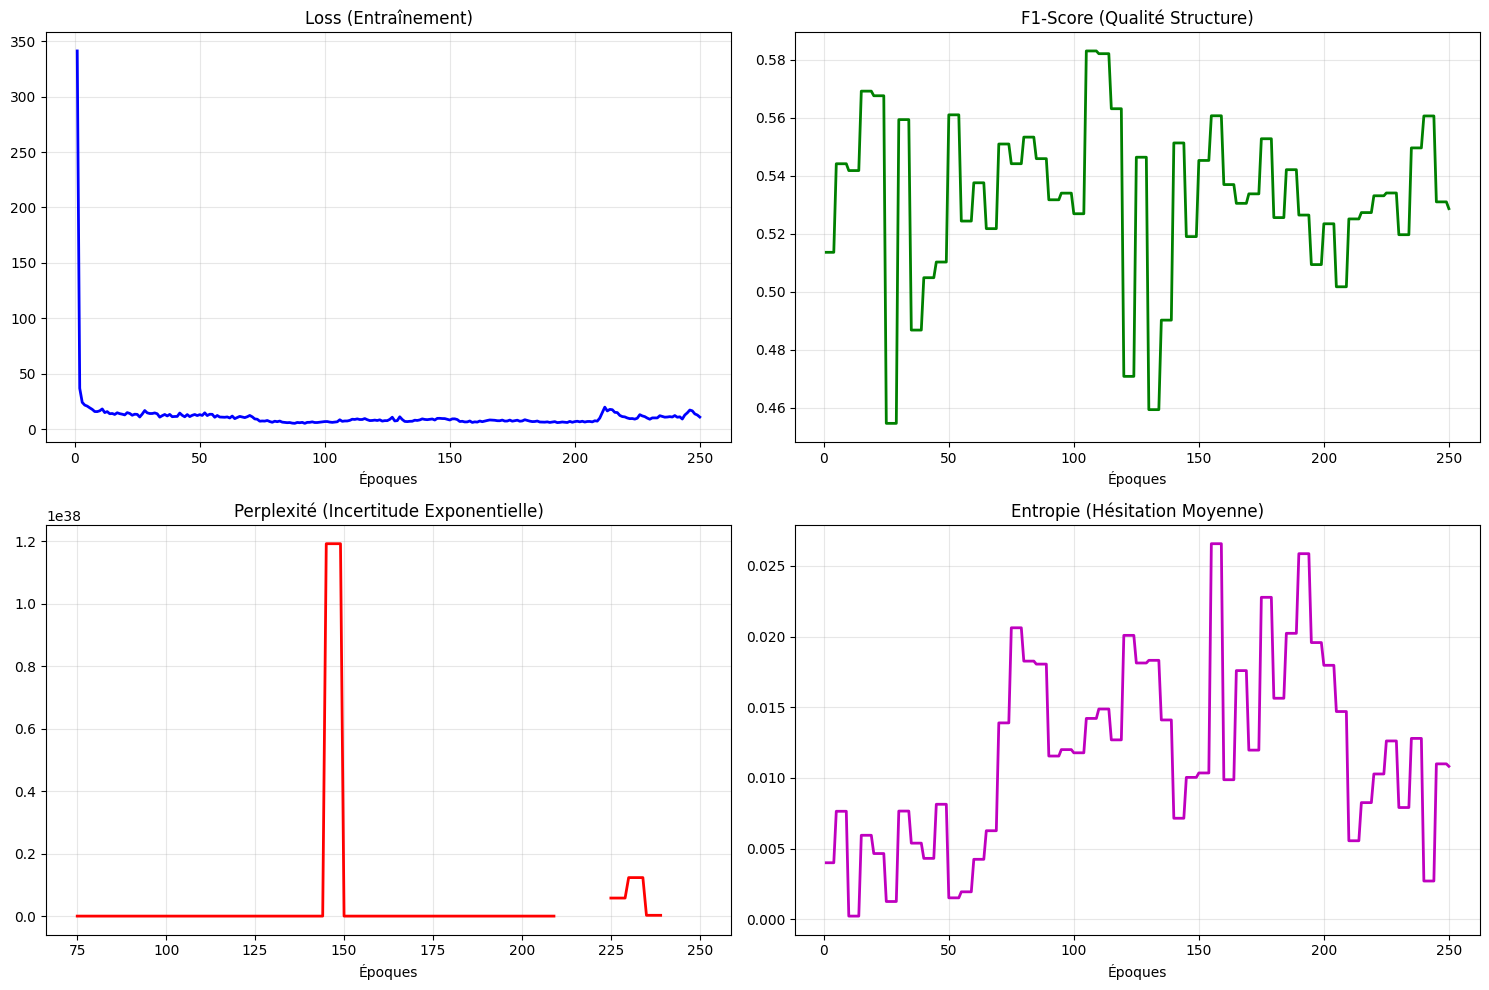


🔍 Calcul de la Matrice de Confusion sur la Validation...


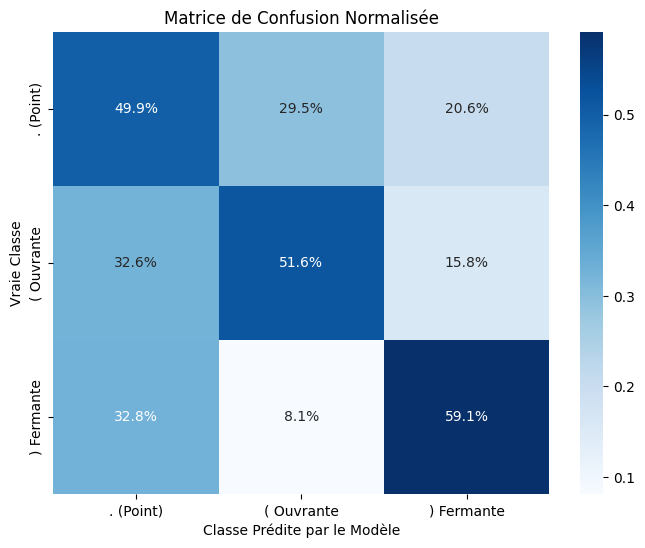

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ==============================================================================
# COURBES D'APPRENTISSAGE (Metrics)
# ==============================================================================
def plot_metrics(history):
    epochs = range(1, len(history['loss']) + 1)
    
    plt.figure(figsize=(15, 10))
    
    # Plot Loss
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Training Loss', linewidth=2)
    plt.title('Loss (Entraînement)')
    plt.xlabel('Époques')
    plt.grid(True, alpha=0.3)
    
    # Plot F1-Score
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['f1'], 'g-', label='Validation F1', linewidth=2)
    plt.title('F1-Score (Qualité Structure)')
    plt.xlabel('Époques')
    plt.grid(True, alpha=0.3)
    
    # Plot Perplexity
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['perplexity'], 'r-', label='Perplexity', linewidth=2)
    plt.title('Perplexité (Incertitude Exponentielle)')
    plt.xlabel('Époques')
    plt.grid(True, alpha=0.3)

    # Plot Entropy
    plt.subplot(2, 2, 4)
    plt.plot(epochs, history['entropy'], 'm-', label='Entropie', linewidth=2)
    plt.title('Entropie (Hésitation Moyenne)')
    plt.xlabel('Époques')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if 'history' in locals() and len(history['loss']) > 0:
    print("📊 Affichage des courbes d'apprentissage...")
    plot_metrics(history)
else:
    print("⚠️ Pas d'historique trouvé. Lancez l'entraînement d'abord.")

# ==============================================================================
# MATRICE DE CONFUSION (Analyse des Erreurs)
# ==============================================================================
def plot_confusion(model, x_val, y_val):
    print("\n🔍 Calcul de la Matrice de Confusion sur la Validation...")
    
    # 1. Prédictions
    # On prédit par petits batchs pour éviter de saturer la RAM
    logits_list = []
    ds_val = tf.data.Dataset.from_tensor_slices(x_val).batch(32)
    for bx in ds_val:
        l, _ = model(bx, training=False)
        logits_list.append(l)
    
    logits = tf.concat(logits_list, axis=0)
    preds = tf.argmax(logits, axis=-1).numpy() # [N, L]
    
    # 2. Aplatir et Nettoyer (Enlever le Padding 0)
    y_true_flat = y_val.flatten()
    y_pred_flat = preds.flatten()
    
    # Masque : on ne garde que les vraies données (pas le padding)
    mask = (y_true_flat != 0)
    y_true_clean = y_true_flat[mask]
    y_pred_clean = y_pred_flat[mask]
    
    # 3. Matrice
    # Labels: 1=., 2=(, 3=)
    labels = [1, 2, 3]
    label_names = ['. (Point)', '( Ouvrante', ') Fermante']
    
    cm = confusion_matrix(y_true_clean, y_pred_clean, labels=labels)
    # Normalisation par ligne (pour voir les % d'erreur par classe)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # 4. Affichage
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title('Matrice de Confusion Normalisée')
    plt.ylabel('Vraie Classe')
    plt.xlabel('Classe Prédite par le Modèle')
    plt.show()

# Lancer l'analyse
if 'X_val' in locals() and 'Y_val' in locals():
    plot_confusion(model, X_val, Y_val)
else:
    print("⚠️ X_val et Y_val introuvables. Assurez-vous d'avoir exécuté la cellule précédente.")

In [1]:
model.save_weights("rnatrm_final.weights.keras")

NameError: name 'model' is not defined